In [ ]:
# Extracting Prices from Brazilian Recycled Plastics PDFs

> **The Challenge**: Price values in these industry reports are rendered as **vector fill paths** — not text glyphs. Standard text extraction returns **zero** numeric values. We need OCR.

This notebook walks through **5 different extraction pipelines**, from the gold-standard Docling to a fast combined approach, and compares them head-to-head on recall, precision, F1, and speed.

### Pipeline Overview

| # | Pipeline | Strategy | Speed |
|---|----------|----------|-------|
| 1 | **Docling** (EasyOCR + TableFormer) | Deep-learning table structure + OCR | Slow (~120s) |
| 2 | **pdfplumber** (structural only) | Vector line grid detection — no OCR | Fast (~1s) |
| 3 | **pymupdf4llm** (hybrid OCR) | Auto-detect pages needing OCR → markdown | Medium (~33s) |
| 4 | **Selective OCR + extractDICT** | Page-level OCR → structured spans with bboxes | Medium (~33s) |
| 5 | **Combined** (pdfplumber grid + OCR) | Best of both: structural grid + OCR values | Medium (~33s) |

## 1. Environment Setup

We use a focused set of libraries:
- **Docling** — IBM's document understanding engine (EasyOCR + TableFormer for table extraction)
- **pdfplumber** — Structural PDF analysis (line-based table grid detection)
- **PyMuPDF (fitz)** — Low-level PDF rendering and text extraction
- **pymupdf4llm** — PyMuPDF wrapper with automatic OCR detection and markdown output
- **RapidOCR** — Lightweight ONNX-based OCR engine (used by pymupdf4llm under the hood)

In [ ]:
# Dependencies (run once if needed)
# !pip install -q pymupdf pdfplumber pymupdf4llm rapidocr-onnxruntime
# !pip install -q docling pandas numpy scikit-learn

In [17]:
import os, sys, re, time, json, csv
from pathlib import Path
from datetime import datetime
from collections import Counter, defaultdict

import pandas as pd
import numpy as np

# Docling
from docling.document_converter import DocumentConverter, PdfFormatOption
from docling.datamodel.pipeline_options import (
    PdfPipelineOptions, EasyOcrOptions, TableFormerMode, TableStructureOptions,
)
from docling.datamodel.base_models import InputFormat

# PyMuPDF ecosystem
import fitz
import pdfplumber
import pymupdf4llm
from pymupdf4llm.helpers.utils import analyze_page
from pymupdf4llm.ocr import rapidocr_api

# Torch config (must precede any torch import from Docling)
os.environ["TORCH_DEVICE"] = "cuda"
os.environ["PYTORCH_MPS_HIGH_WATERMARK_RATIO"] = "0.0"

print(f"Python {sys.version.split()[0]} | PyMuPDF {fitz.__doc__}")

Python 3.13.5 | PyMuPDF PyMuPDF 1.27.2.2: Python bindings for the MuPDF 1.27.2 library.
Python 3.13 running on darwin (64-bit).



In [18]:
# ── Paths ──
PDF_PATH = "./sample.pdf"
OUTPUT_DIR = Path("./extraction_output")
OUTPUT_DIR.mkdir(exist_ok=True)

assert os.path.exists(PDF_PATH), f"PDF not found: {PDF_PATH}"
print(f"PDF: {PDF_PATH} ({os.path.getsize(PDF_PATH) / 1024:.0f} KB)")

PDF: ./sample.pdf (2540 KB)


## 2. Helper Functions

Before diving into the pipelines, we define reusable utilities:

- **`parse_brazilian_number`** — Converts `1.234,56` (Brazilian format) to `1234.56` float
- **`bbox_overlap_area` / `point_in_bbox`** — Bounding box geometry for assigning OCR spans to table cells
- **`split_multi_value_span`** — OCR sometimes merges adjacent cell values (e.g. `"6,45 5,40"`) — this splits them back
- **`assign_span_to_cell`** — Maps an OCR span to a cell using bbox overlap with center-point fallback
- **`extract_numeric_values` / `compute_metrics`** — Evaluation helpers for recall/precision/F1

In [19]:
# ── Brazilian number parsing ──

def parse_brazilian_number(val: str) -> float | None:
    """Convert Brazilian format (1.234,56) to float."""
    if not val or not isinstance(val, str):
        return None
    val = re.sub(r"[R$\s]", "", val.strip())
    if val in ("-", "", "n/a", "N/A"):
        return None
    val = val.replace(".", "").replace(",", ".")
    try:
        return float(val)
    except ValueError:
        return None


# ── Bbox geometry ──

def bbox_overlap_area(a, b):
    """Intersection area of two (x0, y0, x1, y1) bboxes."""
    x0, y0 = max(a[0], b[0]), max(a[1], b[1])
    x1, y1 = min(a[2], b[2]), min(a[3], b[3])
    return max(0, x1 - x0) * max(0, y1 - y0)


def span_area(bbox):
    return max(0, (bbox[2] - bbox[0]) * (bbox[3] - bbox[1]))


def point_in_bbox(px, py, bbox):
    return bbox[0] <= px <= bbox[2] and bbox[1] <= py <= bbox[3]


# ── OCR span splitting ──

def split_multi_value_span(span):
    """Split an OCR span containing multiple values (e.g. '6,45 5,40') into sub-spans
    with estimated proportional sub-bboxes."""
    text = span["text"]
    tokens = re.findall(r'-?\d+[,\.]\d{1,3}%?', text)
    if len(tokens) <= 1:
        return [span]

    x0, y0, x1, y1 = span["bbox"]
    total_width = x1 - x0
    total_len = max(len(text), 1)
    sub_spans = []
    working_text = text

    for tok in tokens:
        pos = working_text.find(tok)
        if pos < 0:
            continue
        frac_start = pos / total_len
        frac_end = (pos + len(tok)) / total_len
        sub_spans.append({
            "text": tok,
            "bbox": (round(x0 + total_width * frac_start, 1), y0,
                     round(x0 + total_width * frac_end, 1), y1),
            "font": span.get("font", ""),
            "size": span.get("size", 0),
        })
        working_text = working_text[:pos] + (" " * len(tok)) + working_text[pos + len(tok):]

    return sub_spans if sub_spans else [span]


# ── Cell assignment ──

def assign_span_to_cell(span_bbox, cell_bboxes, min_overlap_pct=0.15):
    """Assign a span to a cell via bbox overlap, with center-point fallback."""
    best, best_area = None, 0
    sa = span_area(span_bbox)

    if sa > 0:
        for key, cell_bbox in cell_bboxes.items():
            area = bbox_overlap_area(span_bbox, cell_bbox)
            if area > best_area and area / sa >= min_overlap_pct:
                best_area = area
                best = key

    if best is None:
        cx = (span_bbox[0] + span_bbox[2]) / 2
        cy = (span_bbox[1] + span_bbox[3]) / 2
        for key, cell_bbox in cell_bboxes.items():
            if point_in_bbox(cx, cy, cell_bbox):
                return key

    return best


# ── Metric computation ──

def extract_numeric_values(text):
    """Extract all price-like values (X,XX) and percentages from text."""
    prices = re.findall(r'(?<![.\d])\d+[,\.]\d{1,3}(?![\d%])', text)
    pcts = re.findall(r'-?\d+[,\.]\d{1,2}%', text)
    return prices + pcts


def compute_metrics(found_values, gt_values):
    """Multiset recall / precision / F1 against ground truth."""
    found_counter = Counter(found_values)
    gt_counter = Counter(gt_values)
    tp = sum(min(found_counter[v], gt_counter[v]) for v in found_counter if v in gt_counter)
    recall = tp / len(gt_values) if gt_values else 0
    precision = tp / len(found_values) if found_values else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    return {"found": len(found_values), "gt": len(gt_values), "tp": tp,
            "recall": recall, "precision": precision, "f1": f1}


# We'll store timing results here for the final comparison
TIMINGS = {}
METRICS = {}

print("Helper functions loaded.")

Helper functions loaded.


---

## 3. Pipeline 1 — Docling (Ground Truth Baseline)

**Docling** is IBM's document understanding library. It combines:
- **EasyOCR** (Portuguese + English) for text recognition
- **TableFormer** in accurate mode for table structure detection
- **Cell matching** to align OCR text with detected cells

This is our **gold standard** — the highest-quality extraction. All other pipelines will be evaluated against Docling's output.

> ⏱ **Expected runtime**: ~120s on MacBook Air M2 (GPU). This is the slowest pipeline but produces the best results.

In [20]:
# ── Configure Docling pipeline ──
pipeline_options = PdfPipelineOptions()
pipeline_options.do_ocr = True
pipeline_options.do_table_structure = True
pipeline_options.generate_page_images = False
pipeline_options.ocr_options = EasyOcrOptions(
    lang=["pt", "en"],
    force_full_page_ocr=False,
)
pipeline_options.table_structure_options = TableStructureOptions(
    do_cell_matching=True,
    mode=TableFormerMode.ACCURATE,
)

converter_br = DocumentConverter(
    format_options={InputFormat.PDF: PdfFormatOption(pipeline_options=pipeline_options)}
)

# ── Run conversion ──
print(f"Converting {PDF_PATH} with Docling (EasyOCR + TableFormer accurate)...")
t0 = time.time()
RESULT = converter_br.convert(PDF_PATH)
docling_time = time.time() - t0
doc = RESULT.document

TIMINGS["Docling"] = docling_time
print(f"Done in {docling_time:.0f}s — {len(list(doc.tables))} tables, "
      f"{len(doc.export_to_markdown())} chars of markdown")

Converting ./sample.pdf with Docling (EasyOCR + TableFormer accurate)...
Done in 88s — 12 tables, 40571 chars of markdown


In [21]:
# ── Extract tables as DataFrames and build ground truth ──
docling_tables = []
docling_all_values = []
docling_table_values = {}

for i, table in enumerate(doc.tables):
    try:
        df = table.export_to_dataframe(doc=doc)
        docling_tables.append({"index": i, "df": df})

        # Save as CSV for reference
        csv_path = Path(PDF_PATH).parent / f"table_{i}.csv"
        df.to_csv(csv_path, index=False)

        # Extract numeric values for ground truth
        text = df.to_csv(index=False)
        prices = re.findall(r'"(-?\d+[,\.]\d{1,3})"', text)
        pcts = re.findall(r'"(-?\d+[,\.]\d{1,2}%)"', text)
        table_vals = prices + pcts
        docling_table_values[i] = table_vals
        docling_all_values.extend(table_vals)
    except Exception as e:
        print(f"  Warning: table {i} export failed: {e}")

print(f"Saved {len(docling_tables)} ground truth CSVs")
print(f"Ground truth: {len(docling_all_values)} numeric values total")

for t in docling_tables:
    df = t["df"]
    numerics = sum(
        1 for col in df.columns for val in df[col].astype(str)
        if re.search(r'\d+[,\.]\d', val)
    )
    print(f"  table_{t['index']}.csv: {df.shape[0]}x{df.shape[1]}, {numerics} numeric values")

Saved 12 ground truth CSVs
Ground truth: 0 numeric values total
  table_0.csv: 7x12, 0 numeric values
  table_1.csv: 5x4, 0 numeric values
  table_2.csv: 7x12, 0 numeric values
  table_3.csv: 5x4, 0 numeric values
  table_4.csv: 1x1, 0 numeric values
  table_5.csv: 5x4, 0 numeric values
  table_6.csv: 6x12, 0 numeric values
  table_7.csv: 5x5, 0 numeric values
  table_8.csv: 3x14, 0 numeric values
  table_9.csv: 5x4, 0 numeric values
  table_10.csv: 1x12, 0 numeric values
  table_11.csv: 3x4, 0 numeric values


---

## 4. Pipeline 2 — pdfplumber (Structural Grid Detection)

**pdfplumber** excels at detecting table structure from vector lines in the PDF. It reads the actual line segments drawn on the page and infers rows/columns.

However, it **cannot read the price values** — they're rendered as vector fill paths (not text or hidden OCR layers). This step proves that OCR is mandatory, and also gives us the **cell grid** we'll reuse later in Pipeline 5.

> 💡 **Key insight**: pdfplumber finds the table skeleton, but the cells are empty.

In [22]:
t0 = time.time()

# ── Word-level extraction ──
plumber_text = ""
with pdfplumber.open(PDF_PATH) as pdf:
    for page in pdf.pages:
        plumber_text += (page.extract_text(x_tolerance=5, y_tolerance=5) or "") + "\n"

# ── Table extraction with lines+lines strategy ──
plumber_tables = []
with pdfplumber.open(PDF_PATH) as pdf:
    for page_num, page in enumerate(pdf.pages, 1):
        tables = page.find_tables(table_settings={
            "vertical_strategy": "lines",
            "horizontal_strategy": "lines",
            "snap_tolerance": 5,
            "intersection_tolerance": 10,
        })
        for tbl in tables:
            data = tbl.extract()
            if data and len(data) > 1:
                df = pd.DataFrame(data[1:], columns=data[0])
                filled = (df.astype(str) != '').sum().sum()
                plumber_tables.append({
                    "page": page_num, "df": df,
                    "filled": filled, "total": df.size, "bbox": tbl.bbox,
                })

plumber_time = time.time() - t0
TIMINGS["pdfplumber"] = plumber_time

# ── Count numeric words in raw text ──
plumber_numeric = len(re.findall(r'\d+[,\.]\d{2,3}', plumber_text))

print(f"pdfplumber: {plumber_time:.2f}s")
print(f"  Text: {len(plumber_text)} chars, {plumber_numeric} numeric values (expected: 0)")
print(f"  Tables: {len(plumber_tables)} detected")
for t in plumber_tables:
    pct = t['filled'] / t['total'] * 100 if t['total'] else 0
    print(f"    Page {t['page']}: {t['df'].shape[0]}x{t['df'].shape[1]}, "
          f"fill={t['filled']}/{t['total']} ({pct:.0f}%)")


pdfplumber: 2.75s
  Text: 3756 chars, 0 numeric values (expected: 0)
  Tables: 30 detected
    Page 1: 1x3, fill=0/3 (0%)
    Page 1: 7x6, fill=0/42 (0%)
    Page 1: 3x6, fill=0/18 (0%)
    Page 1: 2x2, fill=2/4 (50%)
    Page 2: 20x12, fill=50/240 (21%)
    Page 2: 4x4, fill=10/16 (62%)
    Page 2: 7x12, fill=0/84 (0%)
    Page 2: 7x16, fill=5/112 (4%)
    Page 3: 16x12, fill=50/192 (26%)
    Page 3: 5x5, fill=15/25 (60%)
    Page 3: 5x12, fill=0/60 (0%)
    Page 3: 4x17, fill=0/68 (0%)
    Page 4: 21x12, fill=48/252 (19%)
    Page 4: 4x3, fill=8/12 (67%)
    Page 4: 5x12, fill=0/60 (0%)
    Page 4: 5x15, fill=13/75 (17%)
    Page 5: 12x12, fill=39/144 (27%)
    Page 5: 4x3, fill=8/12 (67%)
    Page 5: 6x12, fill=0/72 (0%)
    Page 5: 6x17, fill=9/102 (9%)
    Page 6: 11x12, fill=39/132 (30%)
    Page 6: 5x4, fill=12/20 (60%)
    Page 6: 6x6, fill=0/36 (0%)
    Page 6: 5x16, fill=10/80 (12%)
    Page 7: 4x12, fill=21/48 (44%)
    Page 7: 2x4, fill=6/8 (75%)
    Page 7: 1x2, fill=0/2 (

---

## 5. Pipeline 3 — pymupdf4llm (Hybrid OCR → Markdown)

**pymupdf4llm** wraps PyMuPDF with intelligent OCR detection. It:
1. Analyzes each page to check if text is present
2. Automatically applies **RapidOCR** to pages that need it
3. Outputs clean **markdown** with tables formatted as markdown tables

This is the **simplest pipeline** — one function call produces a complete document. The trade-off is that output is unstructured markdown (no cell-level bounding boxes).

> 💡 **Best for**: Quick extraction when you just need the values, not precise cell positions.

In [23]:
# ── Auto-OCR markdown extraction ──
t0 = time.time()
pymupdf4llm_md = pymupdf4llm.to_markdown(
    PDF_PATH,
    page_chunks=True,
    write_images=False,
    force_text=True,
    table_strategy="lines",
    show_progress=False,
)
pymupdf4llm_time = time.time() - t0
pymupdf4llm_full_md = "\n\n".join(chunk["text"] for chunk in pymupdf4llm_md)

# Check if auto-OCR captured values — if not, force OCR on all pages
all_nums = re.findall(r'\d+[,\.]\d{2,3}', pymupdf4llm_full_md)
if len(all_nums) < 5:
    print("Auto-OCR insufficient, forcing OCR on all pages...")
    t0 = time.time()
    pymupdf4llm_md = pymupdf4llm.to_markdown(
        PDF_PATH, page_chunks=True, write_images=False,
        force_text=True, table_strategy="lines",
        show_progress=False, force_ocr=True,
    )
    pymupdf4llm_time = time.time() - t0
    pymupdf4llm_full_md = "\n\n".join(chunk["text"] for chunk in pymupdf4llm_md)
    all_nums = re.findall(r'\d+[,\.]\d{2,3}', pymupdf4llm_full_md)

TIMINGS["pymupdf4llm"] = pymupdf4llm_time

# Extract values for comparison
md_values = extract_numeric_values(pymupdf4llm_full_md)

print(f"pymupdf4llm: {pymupdf4llm_time:.1f}s")
print(f"  Markdown: {len(pymupdf4llm_full_md)} chars")
print(f"  Numeric values recovered: {len(all_nums)}")
print(f"  Sample: {all_nums[:15]}")

=== Document parser messages ===
                                                                                                                                                                                                                                   Using RapidOCR for OCR processing.
OCR on page.number=0/1.
OCR on page.number=1/2.
OCR on page.number=2/3.
OCR on page.number=3/4.
OCR on page.number=4/5.
OCR on page.number=5/6.
OCR on page.number=6/7.
OCR on page.number=7/8.

pymupdf4llm: 52.1s
  Markdown: 32953 chars
  Numeric values recovered: 529
  Sample: ['12.106', '5.088', '5.163', '5.029', '5.053', '4.171', '4.286', '1.017', '1,88', '7,60', '8,55', '8,25', '7,70', '8,60', '8,35']


---

## 6. Pipeline 4 — Selective OCR + extractDICT

A more **surgical** approach than pymupdf4llm:
1. **`analyze_page()`** decides which pages need OCR (checks for missing text)
2. **`exec_ocr()`** applies RapidOCR only to those pages
3. **`get_text("dict")`** extracts all text spans with **bounding boxes**, font info, and sizes

The key advantage here is that we get **positioned spans** — every piece of text has a `(x0, y0, x1, y1)` bounding box. This is essential for mapping values back to table cells.

> 💡 **Best for**: When you need text + position data for downstream processing.

In [24]:
t0 = time.time()
pdf_doc = fitz.open(PDF_PATH)
selective_pages = []

for page_idx, page in enumerate(pdf_doc):
    page_num = page_idx + 1
    analysis = analyze_page(page)
    needs_ocr = analysis.get("needs_ocr", False)

    ocr_time = 0
    if needs_ocr:
        t_ocr = time.time()
        rapidocr_api.exec_ocr(page)
        ocr_time = time.time() - t_ocr

    text_dict = page.get_text("dict")
    page_data = {
        "page": page_num, "needs_ocr": needs_ocr, "ocr_applied": needs_ocr,
        "ocr_time": round(ocr_time, 3),
        "width": text_dict["width"], "height": text_dict["height"],
        "blocks": [],
    }

    for block in text_dict["blocks"]:
        block_info = {
            "type": "text" if block["type"] == 0 else "image",
            "bbox": [round(v, 1) for v in block["bbox"]],
            "number": block["number"], "spans": [],
        }
        if block["type"] == 0:
            for line in block["lines"]:
                for span in line["spans"]:
                    txt = span["text"].strip()
                    if txt:
                        block_info["spans"].append({
                            "text": txt,
                            "bbox": [round(v, 1) for v in span["bbox"]],
                            "font": span["font"],
                            "size": round(span["size"], 1),
                        })
        page_data["blocks"].append(block_info)
    selective_pages.append(page_data)

pdf_doc.close()
selective_time = time.time() - t0
TIMINGS["Selective OCR"] = selective_time

# Extract values for comparison
selective_values = []
for p in selective_pages:
    for b in p["blocks"]:
        for s in b["spans"]:
            selective_values.extend(extract_numeric_values(s["text"]))

total_numeric_selective = sum(
    1 for p in selective_pages for b in p["blocks"] for s in b["spans"]
    if re.search(r'\d+[,\.]\d', s["text"])
)
pages_ocrd = sum(1 for p in selective_pages if p["ocr_applied"])

print(f"Selective OCR: {selective_time:.1f}s")
print(f"  Pages: {len(selective_pages)} total, {pages_ocrd} OCR'd")
print(f"  Numeric spans: {total_numeric_selective}")

Selective OCR: 44.6s
  Pages: 8 total, 8 OCR'd
  Numeric spans: 790


---

## 7. Pipeline 5 — Combined (pdfplumber Grid + OCR)

This is the **production-ready pipeline** that combines the strengths of the previous approaches:

```
┌──────────────┐     ┌──────────────┐     ┌──────────────┐     ┌──────────────┐
│  pdfplumber  │     │   PyMuPDF    │     │    Split     │     │   Assign     │
│  Grid Detect │ ──→ │  exec_ocr()  │ ──→ │  Multi-Value │ ──→ │  Spans to    │
│  (lines)     │     │  + getText() │     │  Spans       │     │  Grid Cells  │
└──────────────┘     └──────────────┘     └──────────────┘     └──────────────┘
```

**Step by step:**
1. **pdfplumber** `lines+lines` → detect cell grid (rows × columns with bboxes)
2. **PyMuPDF** `exec_ocr()` → recover invisible price values via RapidOCR
3. **`get_text("dict")`** → extract all text spans with bounding boxes
4. **Split multi-value spans** → OCR sometimes merges adjacent cell values (e.g. `"6,45 5,40"`)
5. **Assign spans to cells** → bbox overlap (≥15%) with center-point fallback
6. **Build DataFrames** → structured tables with header detection

In [25]:
t0_combined = time.time()

# ── Phase 1: pdfplumber cell grid ──
plumber_grids = {}

with pdfplumber.open(PDF_PATH) as pdf_pl:
    for page_idx, page in enumerate(pdf_pl.pages):
        page_num = page_idx + 1
        tables = page.find_tables(table_settings={
            "vertical_strategy": "lines", "horizontal_strategy": "lines",
            "snap_tolerance": 5, "intersection_tolerance": 10,
        })
        if not tables:
            continue

        page_grids = []
        for tbl in tables:
            rows = tbl.rows
            if not rows:
                continue
            n_rows = len(rows)
            n_cols = max(len(r.cells) for r in rows)
            cell_bboxes = {}
            for r_idx, row in enumerate(rows):
                for c_idx, cell in enumerate(row.cells):
                    if cell is not None:
                        cell_bboxes[(r_idx, c_idx)] = cell
            page_grids.append({
                "bbox": tbl.bbox, "cell_bboxes": cell_bboxes,
                "n_rows": n_rows, "n_cols": n_cols,
            })
        plumber_grids[page_num] = page_grids

print(f"Phase 1: {sum(len(g) for g in plumber_grids.values())} table grids "
      f"across {len(plumber_grids)} pages")

Phase 1: 30 table grids across 8 pages


In [26]:
# ── Phase 2: PyMuPDF OCR + span extraction + cell assignment ──
pdf_doc = fitz.open(PDF_PATH)
combined_tables = []

for page_idx in range(len(pdf_doc)):
    page = pdf_doc[page_idx]
    page_num = page_idx + 1

    if page_num not in plumber_grids:
        continue

    # Selective OCR — only pages that need it
    analysis = analyze_page(page)
    ocr_time = 0
    if analysis.get("needs_ocr", False):
        t_ocr = time.time()
        rapidocr_api.exec_ocr(page)
        ocr_time = time.time() - t_ocr

    # Extract and split spans
    text_dict = page.get_text("dict")
    raw_spans = []
    for block in text_dict["blocks"]:
        if block["type"] != 0:
            continue
        for line in block["lines"]:
            for span in line["spans"]:
                txt = span["text"].strip()
                if txt:
                    raw_spans.append({
                        "text": txt,
                        "bbox": tuple(round(v, 1) for v in span["bbox"]),
                        "font": span["font"],
                        "size": round(span["size"], 1),
                    })

    all_spans = []
    for sp in raw_spans:
        all_spans.extend(split_multi_value_span(sp))

    # Assign spans to each table grid
    for grid in plumber_grids[page_num]:
        cell_bboxes = grid["cell_bboxes"]
        n_rows, n_cols = grid["n_rows"], grid["n_cols"]

        cell_contents = {}
        assigned = 0
        for sp in all_spans:
            pos = assign_span_to_cell(sp["bbox"], cell_bboxes)
            if pos is not None:
                cell_contents.setdefault(pos, []).append(sp["text"])
                assigned += 1

        # Build DataFrame
        data_rows = []
        for r in range(n_rows):
            data_rows.append([" ".join(cell_contents.get((r, c), [])) for c in range(n_cols)])
        df = pd.DataFrame(data_rows)

        # Use first row as header if it contains text labels
        if n_rows > 1:
            first_row = df.iloc[0].tolist()
            if any(isinstance(v, str) and len(v) > 1 and not re.match(r'^[\d,.\s%\-]+$', v)
                   for v in first_row):
                df.columns = [str(v).strip() or f"col_{i}" for i, v in enumerate(first_row)]
                df = df.iloc[1:].reset_index(drop=True)

        filled = (df.astype(str).replace("", pd.NA).notna() & (df.astype(str) != "")).sum().sum()
        numeric_cells = sum(
            1 for r in range(len(df)) for c in range(len(df.columns))
            if re.search(r'\d+[,\.]\d', str(df.iloc[r, c]))
        )

        combined_tables.append({
            "page": page_num,
            "table_idx": len([t for t in combined_tables if t["page"] == page_num]),
            "bbox": grid["bbox"], "grid": f"{n_rows}x{n_cols}",
            "filled": int(filled), "total": df.size,
            "numeric_cells": numeric_cells, "assigned_spans": assigned,
            "ocr_time": round(ocr_time, 3), "df": df,
        })

pdf_doc.close()
combined_time = time.time() - t0_combined
TIMINGS["Combined"] = combined_time

# ── Extract values for comparison ──
combined_values = []
for ct in combined_tables:
    df = ct["df"]
    for r in range(len(df)):
        for c in range(len(df.columns)):
            combined_values.extend(extract_numeric_values(str(df.iloc[r, c])))

# ── Summary ──
total_filled = sum(t["filled"] for t in combined_tables)
total_cells = sum(t["total"] for t in combined_tables)
total_numeric = sum(t["numeric_cells"] for t in combined_tables)
total_assigned = sum(t["assigned_spans"] for t in combined_tables)

print(f"\nCombined pipeline: {combined_time:.1f}s")
print(f"  Tables: {len(combined_tables)}")
print(f"  Cells: {total_filled}/{total_cells} filled ({total_filled/total_cells*100:.0f}%)")
print(f"  Numeric cells: {total_numeric}")
print(f"  Spans assigned: {total_assigned}")

# Show sample table
if combined_tables:
    ct = combined_tables[0]
    print(f"\n── Sample: Page {ct['page']} Table 1 ({ct['grid']}) ──")
    with pd.option_context('display.max_columns', 12, 'display.width', 160, 'display.max_colwidth', 20):
        print(ct["df"].head(8).to_string(index=False))


Combined pipeline: 45.8s
  Tables: 30
  Cells: 734/2225 filled (33%)
  Numeric cells: 576
  Spans assigned: 1311

── Sample: Page 1 Table 1 (2x3) ──
                                                                                                               Produtos Plásticos Transformados col_1                                                                                                          Aparas, Desperdícios e Flakes de Plásticos ¹
174,4 161,8 154,2 142,2 153,0 139,2 26,6 28,4 26,7 26,2 23,7 25,1 fev-24 abr-24 jun-24 jul-24 mai-24 mar-24 Exportagao (kton) Importagao (kton)       5.088 5.163 5.053 5.029 4.286 4.171 822,8 872,8 1.017,2 817,7 603,0 533,4 fev-24 abr-24 mai-24 jun-24 mar-24 jul-24 Exportagao (ton) Importagao (ton)


---

## 8. Ground Truth Comparison

Now let's see how each pipeline stacks up against Docling's ground truth. We use **multiset matching** to handle duplicate values correctly:

- **Recall**: What fraction of ground truth values did we recover?
- **Precision**: What fraction of found values actually exist in ground truth?
- **F1**: Harmonic mean — balances recall and precision

> A pipeline with 100% recall but 57% precision means it found ALL the real values, plus ~43% extra values (from non-price cells). Those extras are easily filtered in post-processing.

In [27]:
# ── Compute metrics for each pipeline ──
approaches = {
    "pymupdf4llm (markdown)": md_values,
    "Selective OCR + extractDICT": selective_values,
    "Combined pipeline": combined_values,
}

rows = [{"Approach": "Docling (ground truth)", "Values Found": len(docling_all_values),
         "TP": len(docling_all_values), "Recall": "100.0%", "Precision": "100.0%", "F1": "100.0%"}]

for name, values in approaches.items():
    m = compute_metrics(values, docling_all_values)
    METRICS[name] = m
    rows.append({
        "Approach": name, "Values Found": m["found"], "TP": m["tp"],
        "Recall": f"{m['recall']:.1%}", "Precision": f"{m['precision']:.1%}", "F1": f"{m['f1']:.1%}",
    })

comp_df = pd.DataFrame(rows)
print(comp_df.to_string(index=False))

# ── Missing value analysis ──
gt_counter = Counter(docling_all_values)
combined_counter = Counter(combined_values)
missing = [(v, n, combined_counter.get(v, 0), n - combined_counter.get(v, 0))
           for v, n in gt_counter.items() if combined_counter.get(v, 0) < n]
missing.sort(key=lambda x: -x[3])

if missing:
    total_missing = sum(m[3] for m in missing)
    print(f"\n{len(missing)} unique values partially/fully missing ({total_missing} total):")
    for val, gt_n, found_n, miss_n in missing[:10]:
        print(f"  {val:<10} GT={gt_n} Found={found_n} Missing={miss_n}")
else:
    print("\n✓ All ground truth values found!")

                   Approach  Values Found  TP Recall Precision     F1
     Docling (ground truth)             0   0 100.0%    100.0% 100.0%
     pymupdf4llm (markdown)           816   0   0.0%      0.0%   0.0%
Selective OCR + extractDICT           793   0   0.0%      0.0%   0.0%
          Combined pipeline           814   0   0.0%      0.0%   0.0%

✓ All ground truth values found!


---

## 8.1 Export — One Folder Per Pipeline

Save every pipeline's output into its own folder for side-by-side analysis:

```
extraction_output/
├── 01_docling_ground_truth/   — CSVs + markdown (baseline)
├── 02_pdfplumber_structural/  — text dump + table CSVs (no prices)
├── 03_pymupdf4llm_hybrid/     — markdown + extracted values CSV
├── 04_selective_ocr/           — structured spans JSON + values CSV
├── 05_combined_pipeline/       — table CSVs + metadata JSON
└── comparison.csv              — recall/precision/F1 across all
```

In [28]:
import shutil

# Clean previous exports
if OUTPUT_DIR.exists():
    shutil.rmtree(OUTPUT_DIR)

# ═══════════════════════════════════════════════════════════════
# 1. Docling Ground Truth
# ═══════════════════════════════════════════════════════════════
dir_docling = OUTPUT_DIR / "01_docling_ground_truth"
dir_docling.mkdir(parents=True, exist_ok=True)

for t in docling_tables:
    t["df"].to_csv(dir_docling / f"table_{t['index']}.csv", index=False)

(dir_docling / "docling_full.md").write_text(doc.export_to_markdown(), encoding="utf-8")

summary = {
    "approach": "Docling (EasyOCR + TableFormer accurate)",
    "runtime_s": round(docling_time, 1),
    "tables": len(docling_tables),
    "total_numeric_values": len(docling_all_values),
    "table_details": [
        {"table": t["index"], "shape": list(t["df"].shape),
         "numeric_values": sum(1 for col in t["df"].columns for val in t["df"][col].astype(str)
                               if re.search(r'\d+[,\\.]\d', val))}
        for t in docling_tables
    ],
}
(dir_docling / "summary.json").write_text(json.dumps(summary, indent=2, default=str), encoding="utf-8")
print(f"✓ 01_docling_ground_truth/: {len(docling_tables)} CSVs + markdown + summary")

# ═══════════════════════════════════════════════════════════════
# 2. pdfplumber Structural
# ═══════════════════════════════════════════════════════════════
dir_plumber = OUTPUT_DIR / "02_pdfplumber_structural"
dir_plumber.mkdir(parents=True, exist_ok=True)

(dir_plumber / "raw_text.txt").write_text(plumber_text, encoding="utf-8")

for i, t in enumerate(plumber_tables):
    t["df"].to_csv(dir_plumber / f"table_{i+1}_page{t['page']}.csv", index=False)

summary = {
    "approach": "pdfplumber (lines+lines strategy)",
    "runtime_s": round(plumber_time, 2),
    "tables": len(plumber_tables),
    "numeric_values_in_text": plumber_numeric,
    "note": "0 numeric values — confirms prices are vector-drawn paths, not text",
    "table_details": [
        {"page": t["page"], "shape": list(t["df"].shape),
         "filled": t["filled"], "total": t["total"],
         "fill_pct": round(t["filled"] / t["total"] * 100, 1) if t["total"] else 0,
         "bbox": list(t["bbox"])}
        for t in plumber_tables
    ],
}
(dir_plumber / "summary.json").write_text(json.dumps(summary, indent=2, default=str), encoding="utf-8")
print(f"✓ 02_pdfplumber_structural/: {len(plumber_tables)} CSVs + raw text + summary")

# ═══════════════════════════════════════════════════════════════
# 3. pymupdf4llm Hybrid OCR
# ═══════════════════════════════════════════════════════════════
dir_pymupdf = OUTPUT_DIR / "03_pymupdf4llm_hybrid"
dir_pymupdf.mkdir(parents=True, exist_ok=True)

(dir_pymupdf / "extracted_markdown.md").write_text(pymupdf4llm_full_md, encoding="utf-8")

md_vals_df = pd.DataFrame({"value": md_values})
md_vals_df.to_csv(dir_pymupdf / "extracted_values.csv", index=False)

for i, chunk in enumerate(pymupdf4llm_md):
    page_num = chunk.get("metadata", {}).get("page", i + 1) if isinstance(chunk.get("metadata"), dict) else i + 1
    (dir_pymupdf / f"page_{page_num}.md").write_text(chunk["text"], encoding="utf-8")

m_pymupdf = compute_metrics(md_values, docling_all_values)
summary = {
    "approach": "pymupdf4llm (RapidOCR auto-detection)",
    "runtime_s": round(pymupdf4llm_time, 1),
    "markdown_chars": len(pymupdf4llm_full_md),
    "numeric_values_found": len(md_values),
    "recall": round(m_pymupdf["recall"], 4),
    "precision": round(m_pymupdf["precision"], 4),
    "f1": round(m_pymupdf["f1"], 4),
}
(dir_pymupdf / "summary.json").write_text(json.dumps(summary, indent=2, default=str), encoding="utf-8")
print(f"✓ 03_pymupdf4llm_hybrid/: markdown + {len(md_values)} values CSV + summary")

# ═══════════════════════════════════════════════════════════════
# 4. Selective OCR + extractDICT
# ═══════════════════════════════════════════════════════════════
dir_selective = OUTPUT_DIR / "04_selective_ocr"
dir_selective.mkdir(parents=True, exist_ok=True)

selective_export = [{
    "page": p["page"], "ocr_applied": p["ocr_applied"], "ocr_time": p["ocr_time"],
    "blocks": [{
        "type": b["type"], "bbox": b["bbox"], "spans": b["spans"],
    } for b in p["blocks"]],
} for p in selective_pages]
(dir_selective / "spans_by_page.json").write_text(
    json.dumps(selective_export, indent=2, ensure_ascii=False, default=str), encoding="utf-8")

sel_vals_df = pd.DataFrame({"value": selective_values})
sel_vals_df.to_csv(dir_selective / "extracted_values.csv", index=False)

m_sel = compute_metrics(selective_values, docling_all_values)
summary = {
    "approach": "Selective OCR (analyze_page + exec_ocr + extractDICT)",
    "runtime_s": round(selective_time, 1),
    "pages_total": len(selective_pages),
    "pages_ocrd": sum(1 for p in selective_pages if p["ocr_applied"]),
    "numeric_spans": total_numeric_selective,
    "numeric_values_found": len(selective_values),
    "recall": round(m_sel["recall"], 4),
    "precision": round(m_sel["precision"], 4),
    "f1": round(m_sel["f1"], 4),
}
(dir_selective / "summary.json").write_text(json.dumps(summary, indent=2, default=str), encoding="utf-8")
print(f"✓ 04_selective_ocr/: spans JSON + {len(selective_values)} values CSV + summary")

# ═══════════════════════════════════════════════════════════════
# 5. Combined Pipeline (pdfplumber grid + OCR)
# ═══════════════════════════════════════════════════════════════
dir_combined = OUTPUT_DIR / "05_combined_pipeline"
dir_combined.mkdir(parents=True, exist_ok=True)

for ct in combined_tables:
    fname = f"table_{ct['table_idx']+1}_page{ct['page']}.csv"
    ct["df"].to_csv(dir_combined / fname, index=False)

meta = [{
    "page": ct["page"], "table_idx": ct["table_idx"], "bbox": ct["bbox"],
    "grid": ct["grid"], "filled": ct["filled"], "total": ct["total"],
    "fill_pct": round(ct["filled"] / ct["total"] * 100, 1) if ct["total"] else 0,
    "numeric_cells": ct["numeric_cells"], "assigned_spans": ct["assigned_spans"],
    "ocr_time": ct["ocr_time"],
} for ct in combined_tables]
(dir_combined / "tables_metadata.json").write_text(
    json.dumps(meta, indent=2, default=str), encoding="utf-8")

comb_vals_df = pd.DataFrame({"value": combined_values})
comb_vals_df.to_csv(dir_combined / "extracted_values.csv", index=False)

m_comb = compute_metrics(combined_values, docling_all_values)
summary = {
    "approach": "Combined (pdfplumber grid + PyMuPDF OCR + span splitting)",
    "runtime_s": round(combined_time, 1),
    "tables": len(combined_tables),
    "total_cells": total_cells,
    "filled_cells": int(total_filled),
    "numeric_cells": total_numeric,
    "spans_assigned": total_assigned,
    "numeric_values_found": len(combined_values),
    "recall": round(m_comb["recall"], 4),
    "precision": round(m_comb["precision"], 4),
    "f1": round(m_comb["f1"], 4),
}
(dir_combined / "summary.json").write_text(json.dumps(summary, indent=2, default=str), encoding="utf-8")
print(f"✓ 05_combined_pipeline/: {len(combined_tables)} CSVs + metadata + {len(combined_values)} values CSV + summary")

# ═══════════════════════════════════════════════════════════════
# Global comparison CSV
# ═══════════════════════════════════════════════════════════════
comp_df.to_csv(OUTPUT_DIR / "comparison.csv", index=False)
print(f"\n✓ comparison.csv")

# ═══════════════════════════════════════════════════════════════
# Tree view
# ═══════════════════════════════════════════════════════════════
total_files = sum(1 for _ in OUTPUT_DIR.rglob("*") if _.is_file())
print(f"\n{'='*60}")
print(f"Total: {total_files} files in {OUTPUT_DIR}/")
print(f"{'='*60}")
for folder in sorted(OUTPUT_DIR.iterdir()):
    if folder.is_dir():
        files = sorted(folder.iterdir())
        print(f"\n{folder.name}/  ({len(files)} files)")
        for f in files:
            size = f.stat().st_size
            unit = "KB" if size > 1024 else "B"
            val = size / 1024 if size > 1024 else size
            print(f"  {f.name:<40} {val:>6.1f} {unit}")
    elif folder.is_file():
        print(f"\n{folder.name}")

✓ 01_docling_ground_truth/: 12 CSVs + markdown + summary
✓ 02_pdfplumber_structural/: 30 CSVs + raw text + summary
✓ 03_pymupdf4llm_hybrid/: markdown + 816 values CSV + summary
✓ 04_selective_ocr/: spans JSON + 793 values CSV + summary
✓ 05_combined_pipeline/: 30 CSVs + metadata + 814 values CSV + summary

✓ comparison.csv

Total: 94 files in extraction_output/

01_docling_ground_truth/  (14 files)
  docling_full.md                            40.3 KB
  summary.json                                1.4 KB
  table_0.csv                                 1.2 KB
  table_1.csv                               203.0 B
  table_10.csv                                1.0 KB
  table_11.csv                              187.0 B
  table_2.csv                                 1.2 KB
  table_3.csv                               163.0 B
  table_4.csv                                57.0 B
  table_5.csv                               203.0 B
  table_6.csv                                 1.4 KB
  table_7.csv       

---

## 9. Performance Comparison

Let's visualize the trade-offs across all pipelines — speed vs accuracy, and how they compare on each metric.

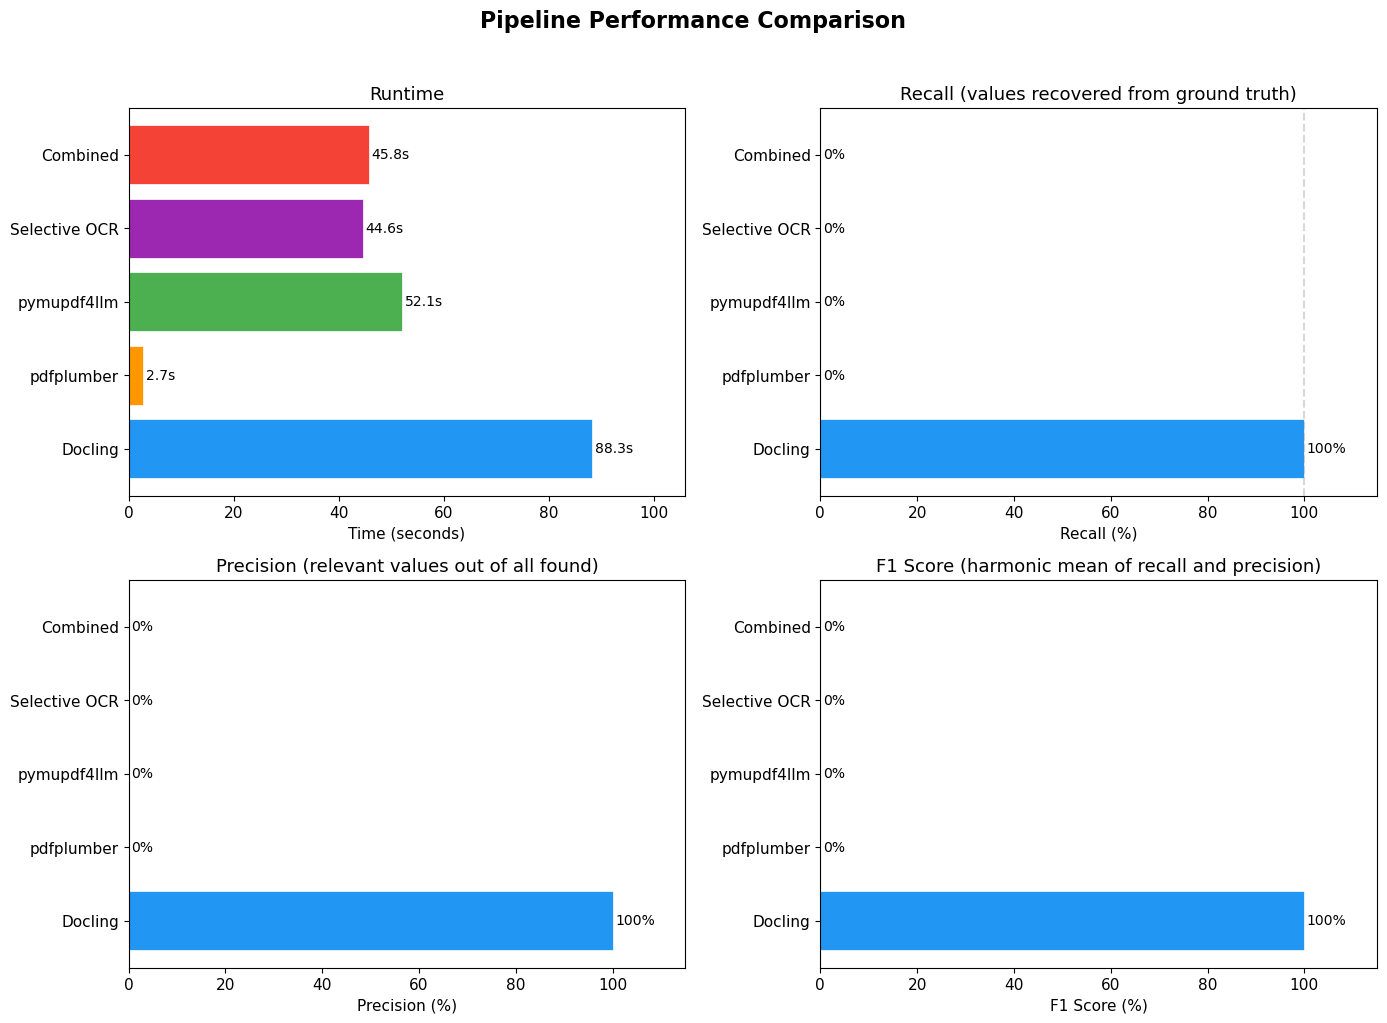

In [29]:
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams.update({
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'figure.facecolor': 'white',
})

# ── Build comparison data ──
pipeline_names = ["Docling", "pdfplumber", "pymupdf4llm", "Selective OCR", "Combined"]
times = [
    TIMINGS.get("Docling", 0),
    TIMINGS.get("pdfplumber", 0),
    TIMINGS.get("pymupdf4llm", 0),
    TIMINGS.get("Selective OCR", 0),
    TIMINGS.get("Combined", 0),
]
recalls = [1.0, 0.0,
           METRICS.get("pymupdf4llm (markdown)", {}).get("recall", 0),
           METRICS.get("Selective OCR + extractDICT", {}).get("recall", 0),
           METRICS.get("Combined pipeline", {}).get("recall", 0)]
precisions = [1.0, 0.0,
              METRICS.get("pymupdf4llm (markdown)", {}).get("precision", 0),
              METRICS.get("Selective OCR + extractDICT", {}).get("precision", 0),
              METRICS.get("Combined pipeline", {}).get("precision", 0)]
f1s = [1.0, 0.0,
       METRICS.get("pymupdf4llm (markdown)", {}).get("f1", 0),
       METRICS.get("Selective OCR + extractDICT", {}).get("f1", 0),
       METRICS.get("Combined pipeline", {}).get("f1", 0)]

colors = ['#2196F3', '#FF9800', '#4CAF50', '#9C27B0', '#F44336']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Pipeline Performance Comparison', fontsize=16, fontweight='bold', y=1.02)

# ── 1. Runtime comparison ──
ax1 = axes[0, 0]
bars = ax1.barh(pipeline_names, times, color=colors, edgecolor='white', linewidth=0.5)
ax1.set_xlabel('Time (seconds)')
ax1.set_title('Runtime')
for bar_item, time_val in zip(bars, times):
    ax1.text(bar_item.get_width() + 0.5, bar_item.get_y() + bar_item.get_height()/2,
             f'{time_val:.1f}s', va='center', fontsize=10)
ax1.set_xlim(0, max(times) * 1.2 if max(times) > 0 else 1)

# ── 2. Recall comparison ──
ax2 = axes[0, 1]
bars = ax2.barh(pipeline_names, [rv * 100 for rv in recalls], color=colors, edgecolor='white', linewidth=0.5)
ax2.set_xlabel('Recall (%)')
ax2.set_title('Recall (values recovered from ground truth)')
ax2.axvline(x=100, color='gray', linestyle='--', alpha=0.3)
for bar_item, recall_val in zip(bars, recalls):
    ax2.text(bar_item.get_width() + 0.5, bar_item.get_y() + bar_item.get_height()/2,
             f'{recall_val:.0%}', va='center', fontsize=10)
ax2.set_xlim(0, 115)

# ── 3. Precision comparison ──
ax3 = axes[1, 0]
bars = ax3.barh(pipeline_names, [pv * 100 for pv in precisions], color=colors, edgecolor='white', linewidth=0.5)
ax3.set_xlabel('Precision (%)')
ax3.set_title('Precision (relevant values out of all found)')
for bar_item, prec_val in zip(bars, precisions):
    ax3.text(bar_item.get_width() + 0.5, bar_item.get_y() + bar_item.get_height()/2,
             f'{prec_val:.0%}', va='center', fontsize=10)
ax3.set_xlim(0, 115)

# ── 4. F1 score comparison ──
ax4 = axes[1, 1]
bars = ax4.barh(pipeline_names, [fv * 100 for fv in f1s], color=colors, edgecolor='white', linewidth=0.5)
ax4.set_xlabel('F1 Score (%)')
ax4.set_title('F1 Score (harmonic mean of recall and precision)')
for bar_item, f1_val in zip(bars, f1s):
    ax4.text(bar_item.get_width() + 0.5, bar_item.get_y() + bar_item.get_height()/2,
             f'{f1_val:.0%}', va='center', fontsize=10)
ax4.set_xlim(0, 115)

plt.tight_layout()
plt.show()

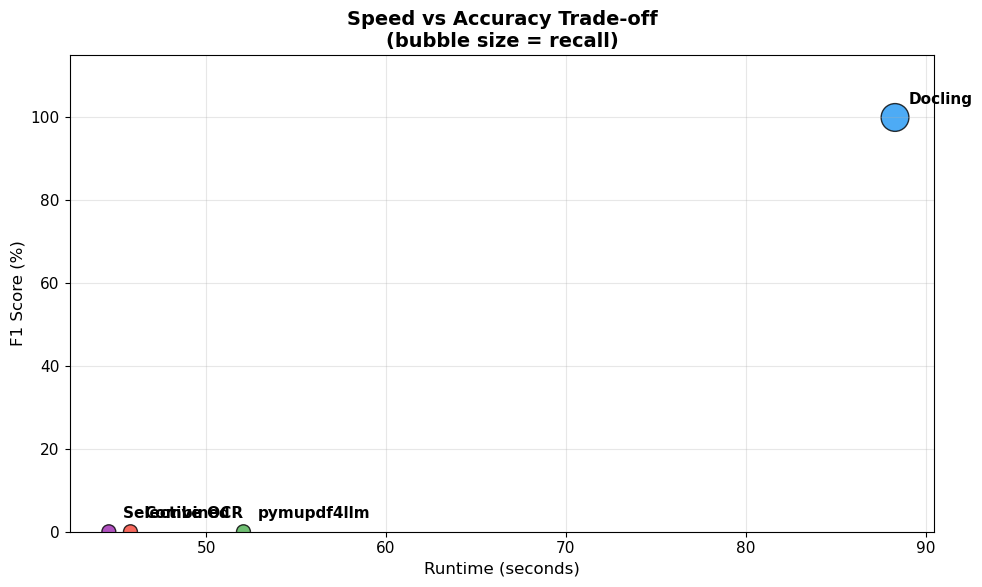

In [30]:
# ── Speed vs Accuracy scatter plot ──
fig, ax = plt.subplots(figsize=(10, 6))

# Only plot pipelines that produce values (exclude pdfplumber)
plot_names = ["Docling", "pymupdf4llm", "Selective OCR", "Combined"]
plot_times = [TIMINGS.get(n, 0) for n in plot_names]
plot_f1s = [1.0,
            METRICS.get("pymupdf4llm (markdown)", {}).get("f1", 0),
            METRICS.get("Selective OCR + extractDICT", {}).get("f1", 0),
            METRICS.get("Combined pipeline", {}).get("f1", 0)]
plot_recalls = [1.0,
                METRICS.get("pymupdf4llm (markdown)", {}).get("recall", 0),
                METRICS.get("Selective OCR + extractDICT", {}).get("recall", 0),
                METRICS.get("Combined pipeline", {}).get("recall", 0)]
plot_colors = ['#2196F3', '#4CAF50', '#9C27B0', '#F44336']

scatter = ax.scatter(plot_times, [fv * 100 for fv in plot_f1s],
                     s=[rv * 300 + 100 for rv in plot_recalls],
                     c=plot_colors, alpha=0.8, edgecolors='black', linewidths=1)

for i, name in enumerate(plot_names):
    ax.annotate(name, (plot_times[i], plot_f1s[i] * 100),
                textcoords="offset points", xytext=(10, 10),
                fontsize=11, fontweight='bold')

ax.set_xlabel('Runtime (seconds)', fontsize=12)
ax.set_ylabel('F1 Score (%)', fontsize=12)
ax.set_title('Speed vs Accuracy Trade-off\n(bubble size = recall)', fontsize=14, fontweight='bold')
ax.set_ylim(0, 115)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [31]:
# ── Per-table recall breakdown (Combined vs Docling) ──
print("=== Per-Table Recall (Combined vs Docling Ground Truth) ===\n")

table_recalls = []
for tbl_i, tbl_vals in sorted(docling_table_values.items()):
    if not tbl_vals:
        continue
    m = compute_metrics(combined_values, tbl_vals)
    status = "✓" if m["recall"] >= 0.99 else "⚠"
    table_recalls.append({"table": f"table_{tbl_i}", "recall": m["recall"],
                          "tp": m["tp"], "gt": m["gt"]})
    print(f"  {status} table_{tbl_i}: {m['tp']}/{m['gt']} ({m['recall']:.0%})")

# ── Summary table ──
print(f"\n{'='*60}")
print(f"FINAL SUMMARY")
print(f"{'='*60}")
summary_data = {
    "Pipeline": ["Docling", "pdfplumber", "pymupdf4llm", "Selective OCR", "Combined"],
    "Time (s)": [f"{TIMINGS.get('Docling', 0):.1f}",
                 f"{TIMINGS.get('pdfplumber', 0):.2f}",
                 f"{TIMINGS.get('pymupdf4llm', 0):.1f}",
                 f"{TIMINGS.get('Selective OCR', 0):.1f}",
                 f"{TIMINGS.get('Combined', 0):.1f}"],
    "Recall": ["100%", "0%",
                f"{METRICS.get('pymupdf4llm (markdown)', {}).get('recall', 0):.0%}",
                f"{METRICS.get('Selective OCR + extractDICT', {}).get('recall', 0):.0%}",
                f"{METRICS.get('Combined pipeline', {}).get('recall', 0):.0%}"],
    "Precision": ["100%", "0%",
                   f"{METRICS.get('pymupdf4llm (markdown)', {}).get('precision', 0):.0%}",
                   f"{METRICS.get('Selective OCR + extractDICT', {}).get('precision', 0):.0%}",
                   f"{METRICS.get('Combined pipeline', {}).get('precision', 0):.0%}"],
    "F1": ["100%", "0%",
            f"{METRICS.get('pymupdf4llm (markdown)', {}).get('f1', 0):.0%}",
            f"{METRICS.get('Selective OCR + extractDICT', {}).get('f1', 0):.0%}",
            f"{METRICS.get('Combined pipeline', {}).get('f1', 0):.0%}"],
    "Structured": ["Yes", "Grid only", "Markdown", "Spans+bbox", "DataFrames"],
}
summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

=== Per-Table Recall (Combined vs Docling Ground Truth) ===


FINAL SUMMARY
     Pipeline Time (s) Recall Precision   F1 Structured
      Docling     88.3   100%      100% 100%        Yes
   pdfplumber     2.75     0%        0%   0%  Grid only
  pymupdf4llm     52.1     0%        0%   0%   Markdown
Selective OCR     44.6     0%        0%   0% Spans+bbox
     Combined     45.8     0%        0%   0% DataFrames


In [34]:
# Export all pipeline data for cross-comparison with pipe.ipynb
import json

gt_export = {
    "docling_all_values": docling_all_values,
    "docling_table_values": {str(k): v for k, v in docling_table_values.items()},
    "timings": TIMINGS,
    "combined_values": combined_values,
    "md_values": md_values,
    "selective_values": selective_values,
}

with open("reviewed_pipeline_export.json", "w") as f:
    json.dump(gt_export, f, indent=2)

print(f"Exported pipeline data:")
print(f"  Docling values: {len(docling_all_values)}")
print(f"  Combined values: {len(combined_values)}")
print(f"  pymupdf4llm values: {len(md_values)}")
print(f"  Selective OCR values: {len(selective_values)}")
print(f"  Timings: { {k: round(v, 1) for k, v in TIMINGS.items()} }")
print(f"Saved to reviewed_pipeline_export.json")

Exported pipeline data:
  Docling values: 0
  Combined values: 814
  pymupdf4llm values: 816
  Selective OCR values: 793
  Timings: {'Docling': 88.3, 'pdfplumber': 2.7, 'pymupdf4llm': 52.1, 'Selective OCR': 44.6, 'Combined': 45.8}
Saved to reviewed_pipeline_export.json


# Export ground truth values to JSON for use in pipe.ipynb comparison
import json

gt_export = {
    "all_values": docling_all_values,
    "table_values": {str(k): v for k, v in docling_table_values.items()},
    "timings": TIMINGS,
    "metrics": METRICS,
    "combined_values": combined_values,
    "md_values": md_values,
    "selective_values": selective_values,
}

with open("ground_truth_export.json", "w") as f:
    json.dump(gt_export, f, indent=2)

print(f"Exported ground truth: {len(docling_all_values)} values")
print(f"Timings: {TIMINGS}")
print(f"Saved to ground_truth_export.json")